In [1]:
%load_ext autoreload
%autoreload 2
from caat import CAAT, DataCube, SN, SNCollection, GP, GP3D, SNModel
import json
import matplotlib.pyplot as plt
import numpy as np
import logging
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel
import glob
import pandas as pd

logger = logging.getLogger()
logger.setLevel(logging.ERROR)

In [2]:
caat = CAAT()

In [ ]:
##################################################################
#
#
#       adding in data, only run if first time ever
#
#
##################################################################

In [138]:
# sn_names = ['SN2018avy', 'SN2019cad', 'SN2019cri', 'SN2019hgp', 'SN2019hty',
#        'SN2019tsf', 'SN2019vsi', 'SN2020adnx', 'SN2020bqj', 'SN2020sgf',
#        'SN2020urc', 'SN2020xpn', 'SN2021gno', 'SN2021hrj', 'SN2022hnt',
#        'SN2022oqm', 'SN2023gwl', 'SN2023psq', 'SN2024zsw', 'SN2025aot']

sn_names = ['SN2019tsf', 'SN2020adnx', 'SN2020urc', 'SN2021gno', 'SN2022hnt', 'SN2023gwl', 'SN2024zsw']

for i, name in enumerate(sn_names):
    try:
        sn = SN(name=name) # Instantiate SN class for single object
        print(name, sn.info) # The metadata for this object
    except:
        print(f"object {name} not in caat database...")

SN2019tsf {}
SN2020adnx {'peak_mjd': 59226.58414225007, 'peak_mag': 17.7797728121255, 'peak_filt': 'g', 'searched': True, 'z': nan, 'ra': 46.481375, 'dec': 41.608711}
SN2020urc {'peak_mjd': 59144.85987639222, 'peak_mag': 18.52798968023504, 'peak_filt': 'g', 'searched': True, 'z': 0.026728, 'ra': 34.5461126, 'dec': 37.097234}
SN2021gno {'peak_mjd': 59305.56318551056, 'peak_mag': 17.49515786162694, 'peak_filt': 'g', 'searched': True, 'z': 0.006211, 'ra': 183.042875, 'dec': 13.249181}
SN2022hnt {'peak_mjd': 60633.64116896331, 'peak_mag': 18.55297303784181, 'peak_filt': 'r', 'searched': True, 'z': 0.0192, 'ra': 174.24897524285714, 'dec': 55.1639571}
SN2023gwl {'peak_mjd': 60080.42424507897, 'peak_mag': 18.939745513031667, 'peak_filt': 'g', 'searched': True, 'z': 0.0346, 'ra': 198.8414944, 'dec': 1.9275673}
SN2024zsw {'peak_mjd': 60633.54660111143, 'peak_mag': 18.551367178525062, 'peak_filt': 'r', 'searched': True, 'z': 0.032286, 'ra': 20.793617, 'dec': 19.570172}


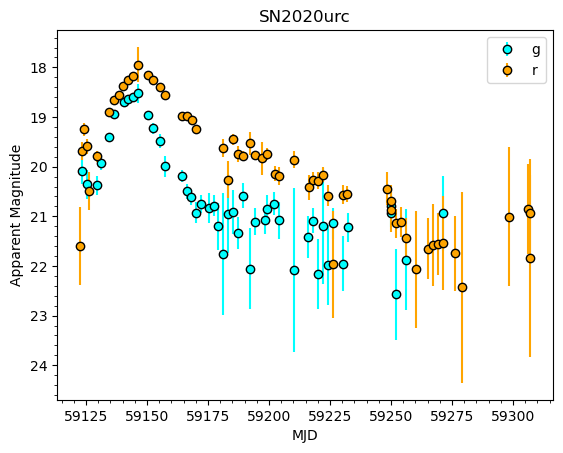

In [70]:
# need to add in ztf data to caat 
# pull from mmmp/temp/gopreaux/*json files for each SN w/o data
# ztf2add = ['ZTF20adadlqm', 'ZTF23aaialcw', 'ZTF24abpdzvm'] done: 'ZTF20acgiglu

with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF20acgiglu_ztf_fp.json', 'r') as file:
    data = json.load(file)
    
with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF20acgiglu_info.json', 'r') as file:
    info = json.load(file)

new_sn = SN(
    name="SN2020urc",
    data=data,
    type="SESNe",
    subtype="SNIIb",
    info=info,
)

new_sn.plot_data()

{'ra': 34.5461126, 'dec': 37.097234, 'z': 0.026728, 'peak_mjd': 59144.85987639222, 'peak_mag': 18.52798968023504, 'peak_filt': 'g', 'searched': True}


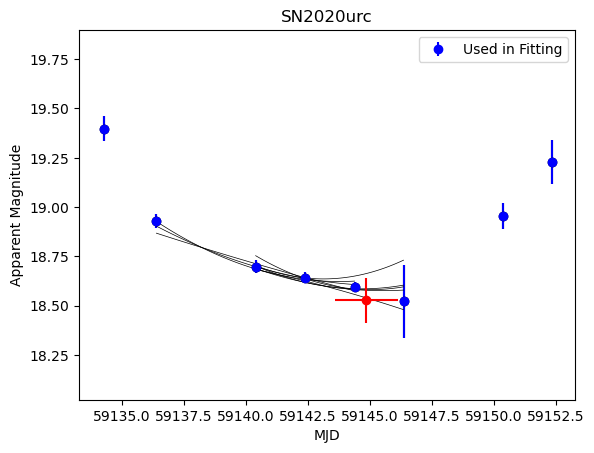

In [71]:
new_sn.fit_for_max(filt="g", plot=True,offset=15)
print(new_sn.info)

In [72]:
# saving the max-fit and SN data to repo
new_sn.write_info_to_caat_file(force=True)
new_sn.write_json_data(dry_run=False)

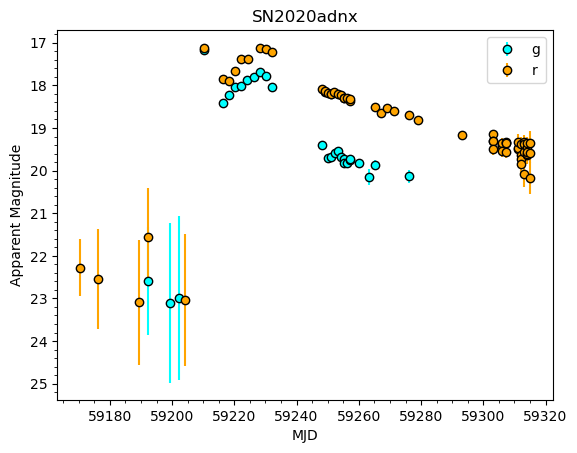

{'ra': 46.481375, 'dec': 41.608711, 'z': 0.021001, 'peak_mjd': 59226.31415931127, 'peak_mag': 17.792909142225035, 'peak_filt': 'g', 'searched': True}


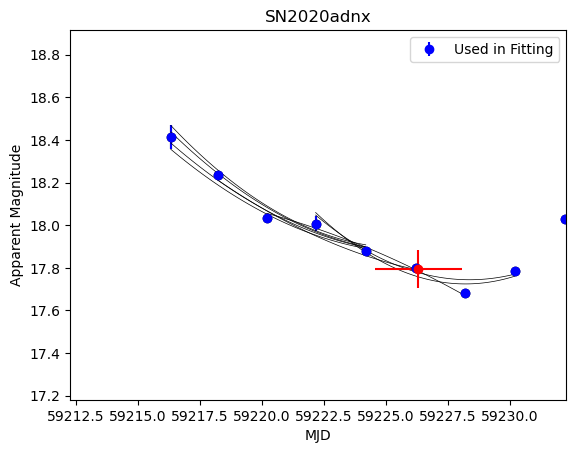

In [139]:
# need to add in ztf data to caat 
# pull from mmmp/temp/gopreaux/*json files for each SN w/o data
# ztf2add = ['ZTF20adadlqm', 'ZTF23aaialcw', 'ZTF24abpdzvm'] done: 'ZTF20acgiglu

with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF20adadlqm_ztf_fp.json', 'r') as file:
    data = json.load(file)
    
with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF20adadlqm_info.json', 'r') as file:
    info = json.load(file)

new_sn = SN(
    name="SN2020adnx",
    data=data,
    type="SESNe",
    subtype="SNIIb",
    info=info,
)

new_sn.plot_data()

new_sn.fit_for_max(filt="g", plot=True, offset=15)
print(new_sn.info)

In [140]:
# saving the max-fit and SN data to repo
new_sn.write_info_to_caat_file(force=True)
new_sn.write_json_data(dry_run=False)

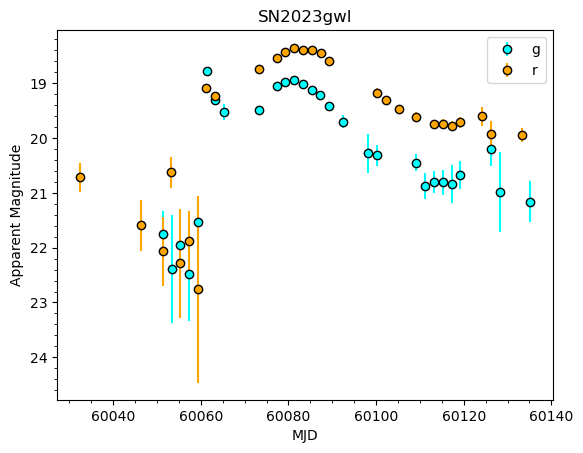

{'ra': 198.8414944, 'dec': 1.9275673, 'z': 0.0346, 'peak_mjd': 60080.42424507897, 'peak_mag': 18.939745513031667, 'peak_filt': 'g', 'searched': True}


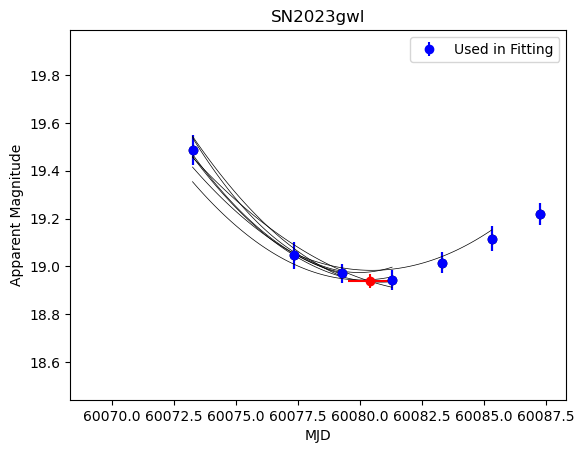

In [75]:
# need to add in ztf data to caat 
# pull from mmmp/temp/gopreaux/*json files for each SN w/o data
# ztf2add = ['ZTF23aaialcw', 'ZTF24abpdzvm'] done: ZTF20acgiglu, ZTF20adadlqm

with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF23aaialcw_ztf_fp.json', 'r') as file:
    data = json.load(file)
    
with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF23aaialcw_info.json', 'r') as file:
    info = json.load(file)

new_sn = SN(
    name="SN2023gwl",
    data=data,
    type="SESNe",
    subtype="SNIIb",
    info=info,
)

new_sn.plot_data()

new_sn.fit_for_max(filt="g", plot=True, offset=15)
print(new_sn.info)

In [76]:
# saving the max-fit and SN data to repo
new_sn.write_info_to_caat_file(force=True)
new_sn.write_json_data(dry_run=False)

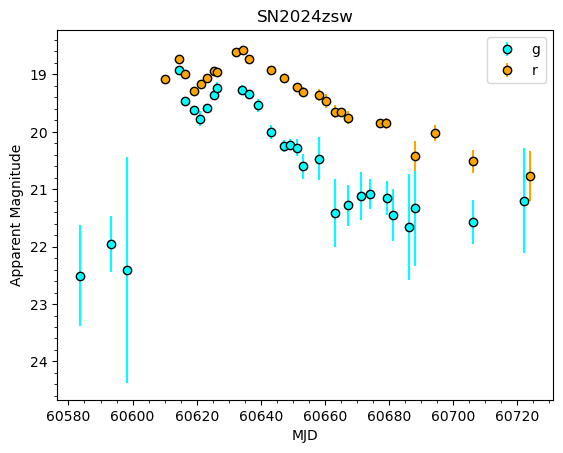

{'ra': 20.793617, 'dec': 19.570172, 'z': 0.032286, 'peak_mjd': 60633.54660111143, 'peak_mag': 18.551367178525062, 'peak_filt': 'r', 'searched': True}


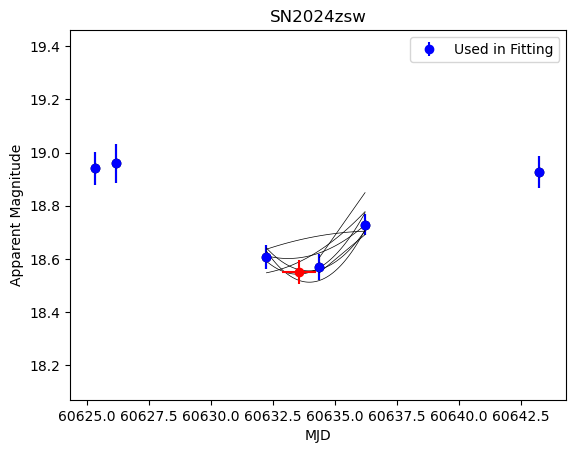

In [77]:
# need to add in ztf data to caat 
# pull from mmmp/temp/gopreaux/*json files for each SN w/o data
# ztf2add = ['ZTF24abpdzvm'] done: ZTF20acgiglu, ZTF20adadlqm, ZTF23aaialcw

with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF24abpdzvm_ztf_fp.json', 'r') as file:
    data = json.load(file)
    
with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF24abpdzvm_info.json', 'r') as file:
    info = json.load(file)

new_sn = SN(
    name="SN2024zsw",
    data=data,
    type="SESNe",
    subtype="SNIIb",
    info=info,
)

new_sn.plot_data()

new_sn.fit_for_max(filt="r", plot=True, offset=20)
print(new_sn.info)

In [78]:
# saving the max-fit and SN data to repo
new_sn.write_info_to_caat_file(force=True)
new_sn.write_json_data(dry_run=False)

In [79]:
#TODO: come back to this object later
# new_sn = SN(
#     name="SN2019tsf",
# )
# new_sn.plot_data(filts_to_plot=['g', 'r'])
# new_sn.fit_for_max(filt="r", plot=True)
# print(new_sn.info)

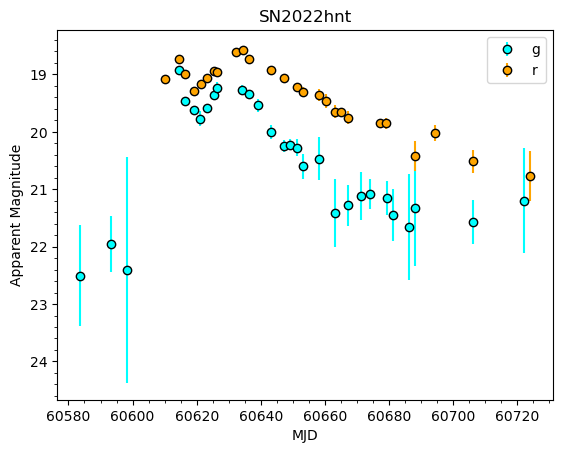

{'ra': 174.2489621, 'dec': 55.1639605, 'z': 0.0192, 'peak_mjd': 60633.64116896331, 'peak_mag': 18.55297303784181, 'peak_filt': 'r', 'searched': True}


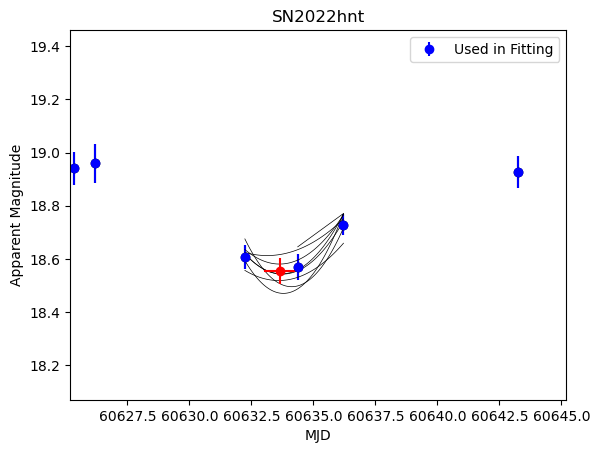

In [94]:
#adding in 22hnt ztf data to caat

with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF22aafrjnw_ztf_fp.json', 'r') as file:
    data = json.load(file)
    
with open('/Users/pnr5sh/Documents/phd/mmmp/adrian/temp/gopreaux/ZTF22aafrjnw_info.json', 'r') as file:
    info = json.load(file)

new_sn = SN(
    name="SN2022hnt",
    data=data,
    type="SESNe",
    subtype="SNIIb",
    info=info,
)

new_sn.plot_data()

new_sn.fit_for_max(filt="r", plot=True)
print(new_sn.info)

In [95]:
# saving the max-fit and SN data to repo
new_sn.write_info_to_caat_file(force=True)
new_sn.write_json_data(dry_run=False)

In [42]:
# double checking the objects now appear in the caat

sn_names = ['SN2020adnx', 'SN2020urc', 'SN2021gno', 'SN2022hnt', 'SN2023gwl', 'SN2024zsw'] #'SN2019tsf'

for i, name in enumerate(sn_names):
    try:
        sn = SN(name=name) # Instantiate SN class for single object
        print(name, sn.info) # The metadata for this object
    except:
        print(f"object {name} not in caat database...")

SN2020adnx {'peak_mjd': 59226.31415931127, 'peak_mag': 17.792909142225035, 'peak_filt': 'g', 'searched': True, 'z': 0.021001, 'ra': 46.481375, 'dec': 41.608711}
SN2020urc {'peak_mjd': 59144.85987639222, 'peak_mag': 18.52798968023504, 'peak_filt': 'g', 'searched': True, 'z': 0.026728, 'ra': 34.5461126, 'dec': 37.097234}
SN2021gno {'peak_mjd': 59305.56318551056, 'peak_mag': 17.49515786162694, 'peak_filt': 'g', 'searched': True, 'z': 0.006211, 'ra': 183.042875, 'dec': 13.249181}
SN2022hnt {'peak_mjd': 60633.64116896331, 'peak_mag': 18.55297303784181, 'peak_filt': 'r', 'searched': True, 'z': 0.0192, 'ra': 174.24897524285714, 'dec': 55.1639571}
SN2023gwl {'peak_mjd': 60080.42424507897, 'peak_mag': 18.939745513031667, 'peak_filt': 'g', 'searched': True, 'z': 0.0346, 'ra': 198.8414944, 'dec': 1.9275673}
SN2024zsw {'peak_mjd': 60633.54660111143, 'peak_mag': 18.551367178525062, 'peak_filt': 'r', 'searched': True, 'z': 0.032286, 'ra': 20.793617, 'dec': 19.570172}


In [43]:
#cube-ing it up

In [45]:
for i, name in enumerate(sn_names):
    sn = SN(name=name)
    cube = DataCube(sn=sn)

    cube.measure_flux_in_filter(plot=False,
                                save=True,
                                overwrite=True)

In [46]:
##################################################################
#
#
#                          doing GP fits
#
#
##################################################################

In [67]:
sn_names = ['SN2020adnx', 'SN2020urc', 'SN2021gno', 'SN2022hnt', 'SN2023gwl', 'SN2024zsw', 'SN2022qzr', 'SN2021pb', 'SN2020sbw', 'SN2020rsc', 'SN2020ikq', ]
#excluding 'SN2016gkg' b/c not enough data in g/r bands

myobjs = SNCollection(names=sn_names)

In [68]:
kernel = RBF([np.log(10.0), np.log10(500.0)], (0.1, 10.0))

# The normalization set provides photometry used to construct residuals, which are then fit
sn_to_normalize = SNCollection(sntype="SESNe", snsubtype='SNIIb')
# sn_to_normalize = myobjs

# filts = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'c', 'V', 'r', 'o', 'i']
filts = ['g', 'r']
phasemin = -20
phasemax = 50
log_transform = 22
mangle_sed = True

gp = GP3D(
    myobjs, 
    kernel, 
    filts,
    phasemin, 
    phasemax,
    set_to_normalize=sn_to_normalize,
    log_transform=log_transform,
    mangle_sed=mangle_sed
)

In [69]:
kernel_parameters = gp.optimize_hyperparams(subtract_polynomial=True)

# Let's look at the kernel hyperparameters
optimized_kernel_hyperparams = np.asarray([np.median([k[i] for k in kernel_parameters]) for i in range(len(kernel_parameters[0]))])
print(np.exp(optimized_kernel_hyperparams))

[ 5.78607541 10.        ]


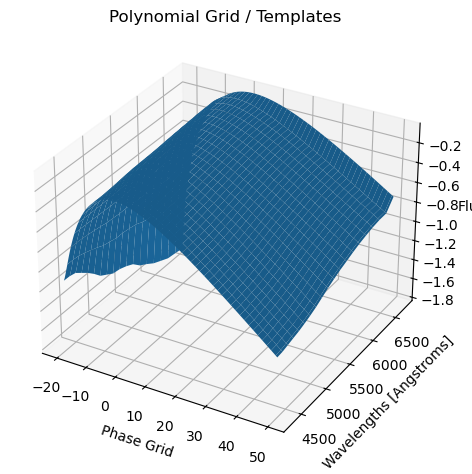

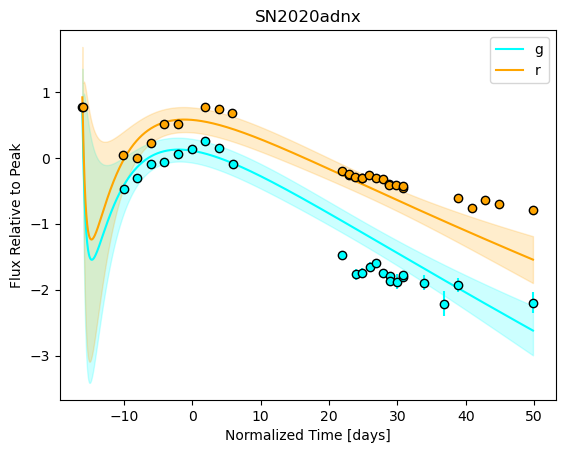

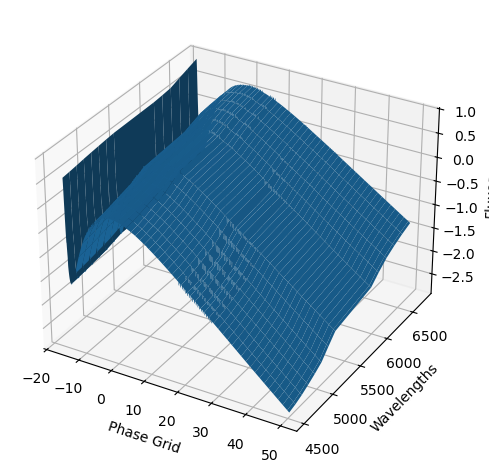

OSError: File /Users/pnr5sh/Documents/phd/gopreaux/data/final_models/SN2020adnx_GP_model.fits already exists. If you mean to replace it then use the argument "overwrite=True".

In [70]:
%matplotlib inline
# sn_model = gp.predict(
#     plot=True,
#     subtract_polynomial=True,
#     fit_separately=True,
# )

sn_model = gp.run_gp_individually(
        plot=True,
        subtract_median=False,
        subtract_polynomial=True,
        interactive=False,
        run_diagnostics=False,
        save_individual_fits=True,
        # overwrite=True,
    )

In [405]:
# creating fake lightcurves with the GPs

In [10]:
dp_models = glob.glob("../data/final_models/SN*_GP_model.fits")
for i,model in enumerate(dp_models):
    print(i,model)

0 ../data/final_models/SN2021pb_GP_model.fits
1 ../data/final_models/SN2021gno_GP_model.fits
2 ../data/final_models/SN2022qzr_GP_model.fits
3 ../data/final_models/SN2023gwl_GP_model.fits
4 ../data/final_models/SN2020sbw_GP_model.fits
5 ../data/final_models/SN2020urc_GP_model.fits
6 ../data/final_models/SN2020rsc_GP_model.fits
7 ../data/final_models/SN2020adnx_GP_model.fits
8 ../data/final_models/SN2020ikq_GP_model.fits
9 ../data/final_models/SN2024zsw_GP_model.fits


In [38]:
sn = 'SN2022hnt'
data = pd.read_csv(f'../data/SESNe/SNIIb/{sn}/{sn}_datacube_mangled.csv')

In [41]:
data.loc[data['Filter']=='r']

,Unnamed: 0,MJD,Phase,Filter,ShiftedFilter,Wavelength,ShiftedWavelength,Flux,ShiftedFlux,Fluxerr,ShiftedFluxerr,Mag,ShiftedMag,Magerr,Nondetection


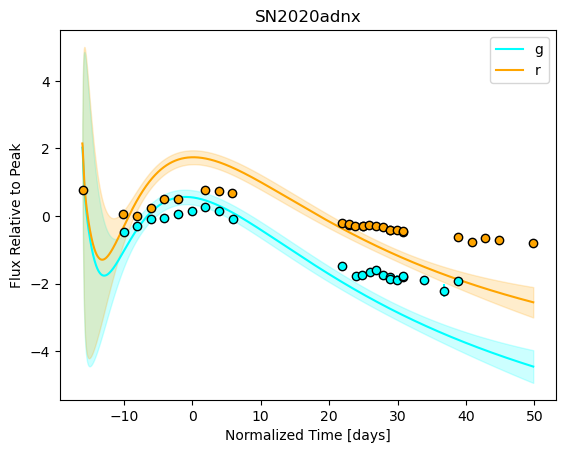

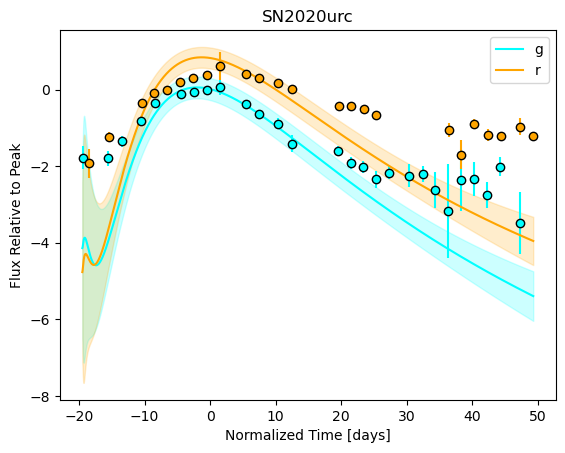

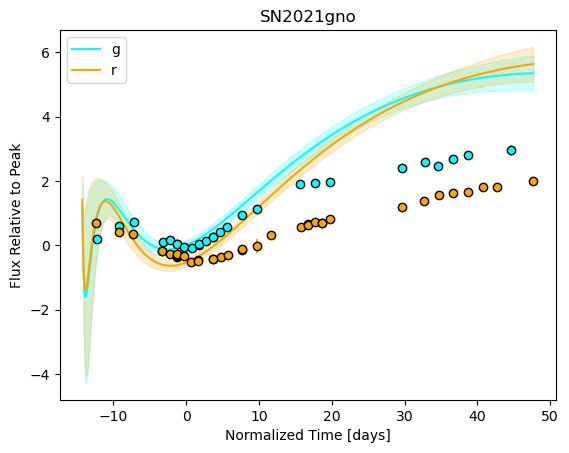

FileNotFoundError: [Errno 2] No such file or directory: '/Users/pnr5sh/Documents/phd/gopreaux/data/final_models/SN2022hnt_GP_model.fits'

In [37]:
for i,sn in enumerate(sn_names):
    model = SNModel(
        surface=f"{sn}_GP_model.fits",
    )

    data = pd.read_csv(f'../data/SESNe/SNIIb/{sn}/{sn}_datacube_mangled.csv')
    datadf = data.loc[(data['Nondetection']==False)&((data['Filter']=='g')|(data['Filter']=='r'))&(data['Phase']>model.min_phase)&(data['Phase']<model.max_phase),
                    ['Phase', 'Filter', 'ShiftedMag', 'Magerr']]
    datadf.rename(columns={'Magerr': 'MagErr'}, inplace=True)
    datadf.rename(columns={'ShiftedMag': 'Mag'}, inplace=True)

    model.fit_photometry(
        photometry=datadf,
        phase_min=model.min_phase,
        phase_max=model.max_phase,
        show=True
    )

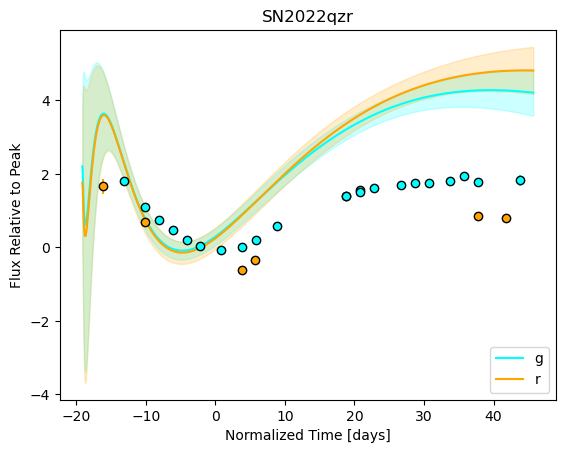

In [36]:
model = SNModel(
        surface="SN2022qzr_GP_model.fits",
    )

data = pd.read_csv('../data/SESNe/SNIIb/SN2022qzr/SN2022qzr_datacube_mangled.csv')
datadf = data.loc[(data['Nondetection']==False)&((data['Filter']=='g')|(data['Filter']=='r'))&(data['Phase']>model.min_phase)&(data['Phase']<model.max_phase),
                  ['Phase', 'Filter', 'ShiftedMag', 'Magerr']]
datadf.rename(columns={'Magerr': 'MagErr'}, inplace=True)
datadf.rename(columns={'ShiftedMag': 'Mag'}, inplace=True)

model.fit_photometry(
    photometry=datadf,
    phase_min=model.min_phase,
    phase_max=model.max_phase,
    show=True
)

In [29]:
datadf['Mag']

1      19.206283
2      18.496846
3      18.147597
4      17.872808
5      17.609719
6      17.448081
7      17.341790
8      17.411298
9      17.615536
10     17.983411
11     18.813060
12     18.815990
13     18.974443
14     18.915523
15     19.015627
16     19.098666
17     19.167333
18     19.168329
19     19.209068
20     19.347575
21     19.184721
22     19.232758
319    19.066614
320    18.109807
321    16.782826
322    17.057527
323    18.262385
324    18.211614
Name: Mag, dtype: float64

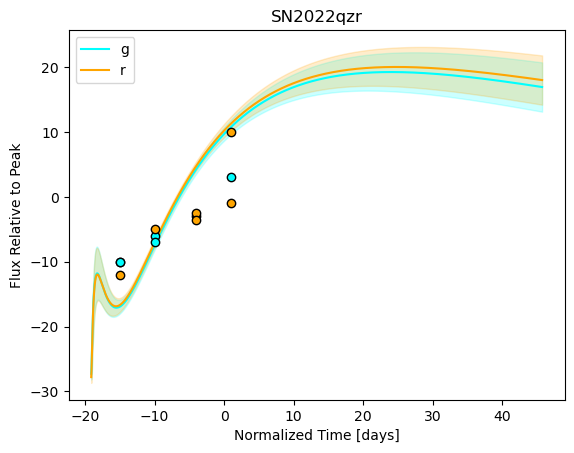

In [ ]:
#test

model = SNModel(
    # surface="SESNe_SNIIb_GP_model.fits",
    surface="SN2022qzr_GP_model.fits"
)

mock_photometry_values = {
    "Filter": ["g", "g", "g", "g", "g", "g", "r", "r", "r", "r", "r", "r"],
    "Phase": [-15.0, -10.0, -4.0, 1.0, -15.0, -10.0, -4.0, 1.0, -15.0, -10.0, -4.0, 1.0],
    # "Mag": [-10.0, -6.0, -3.0, 3.0, -10.1, -7.0, -2.5, 10.0, -12.0, -5.0, -3.5, -1.0],
    "Mag": [-10.0, -6.0, -3.0, 3.0, -10.1, -7.0, -2.5, 10.0, -12.0, -5.0, -3.5, -1.0],
    "MagErr": [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
}

mock_photometry_values_df = pd.DataFrame(mock_photometry_values)

model.fit_photometry(
    photometry=mock_photometry_values_df,
    phase_min=model.min_phase,
    phase_max=model.max_phase,
    show=True,
)

In [33]:
mock_photometry_values_df

,Filter,Phase,Mag,MagErr
0,g,-15.0,-10.0,0.1
1,g,-10.0,-6.0,0.1
2,g,-4.0,-3.0,0.1
3,g,1.0,3.0,0.1
4,g,-15.0,-10.1,0.1
5,g,-10.0,-7.0,0.1
6,r,-4.0,-2.5,0.1
7,r,1.0,10.0,0.1
8,r,-15.0,-12.0,0.1
9,r,-10.0,-5.0,0.1


In [34]:
datadf

,Phase,Filter,Mag,MagErr
1,-13.155843,g,19.206283,0.099044
2,-10.169778,g,18.496846,0.035734
3,-8.127035,g,18.147597,0.020594
4,-6.133123,g,17.872808,0.016963
5,-4.117498,g,17.609719,0.013882
6,-2.183505,g,17.448081,0.012363
7,0.812525,g,17.341790,0.011741
8,3.845673,g,17.411298,0.012489
9,5.821078,g,17.615536,0.030457
10,8.842201,g,17.983411,0.025554


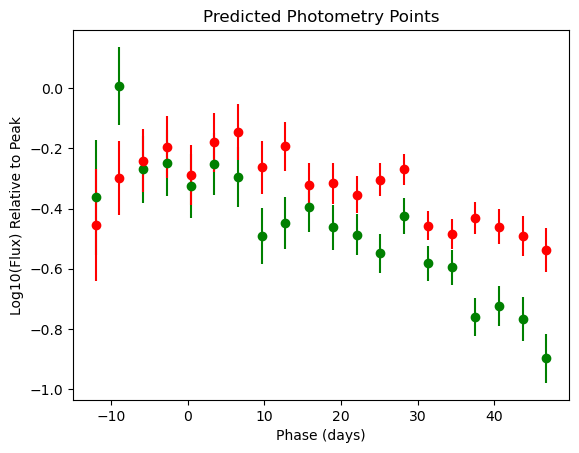

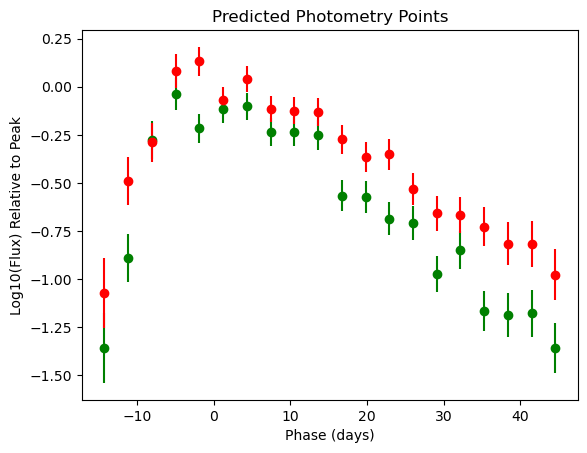

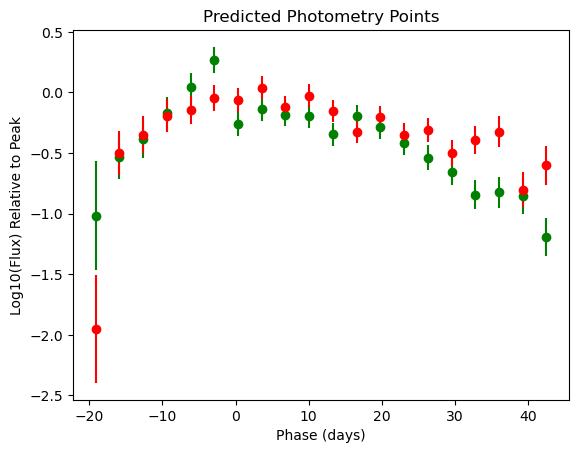

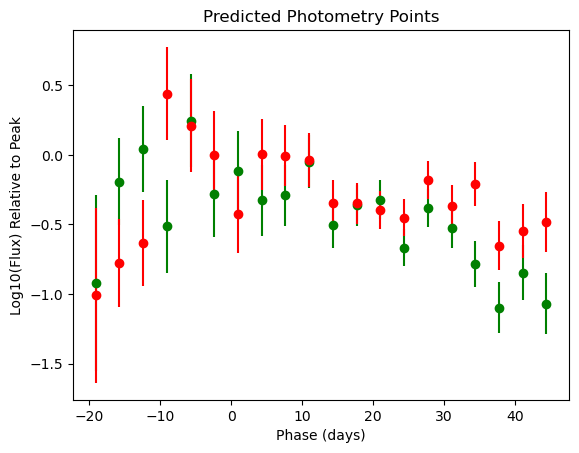

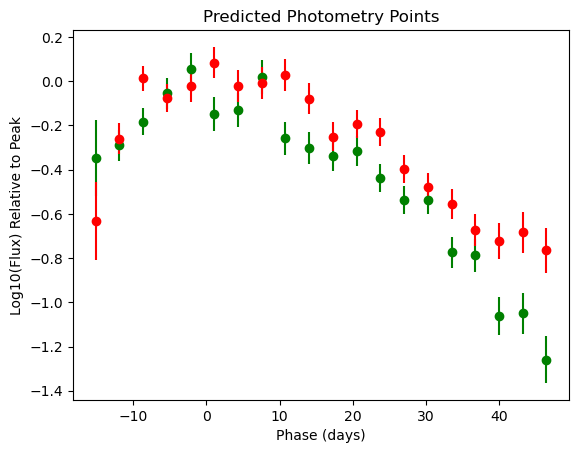

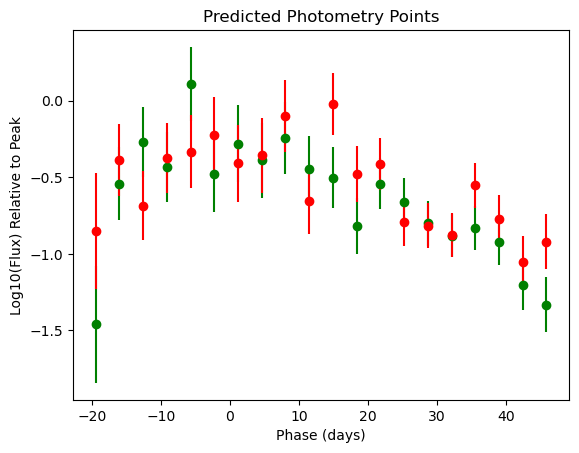

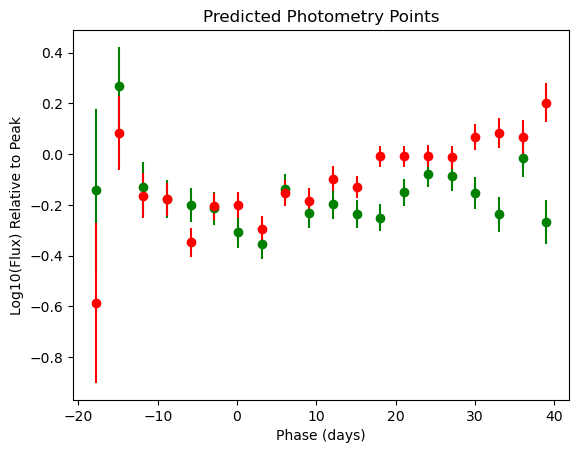

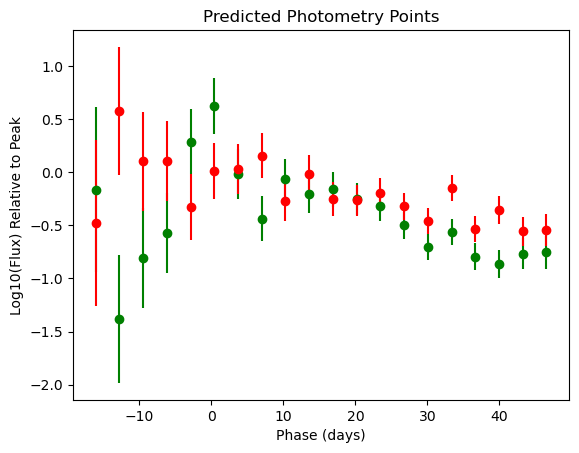

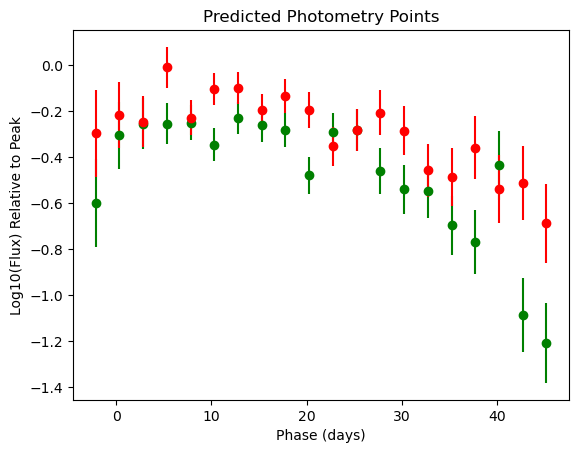

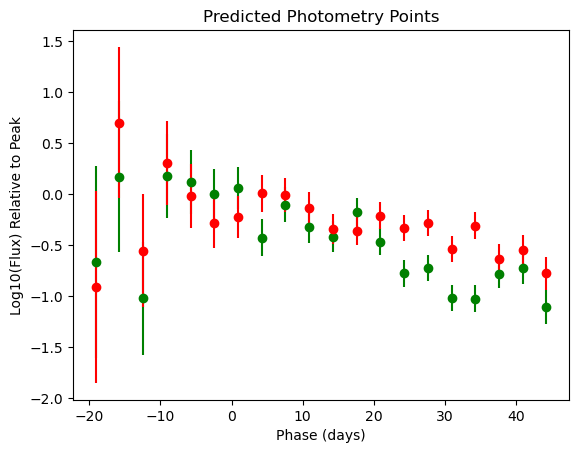

In [ ]:
dp_models = glob.glob("../data/final_models/SN*_GP_model.fits")

for i,mod in enumerate(dp_models):
    surface = mod[21:]
    model = SNModel(
        surface=surface,
    )

    time = np.arange(model.min_phase,model.max_phase,(abs(model.min_phase)+abs(model.max_phase))/20) #TODO make random selection of 20 obs +/- 5 points
    gband = np.ones(20)*4830
    rband = np.ones(20)*6260
    bands = np.append(gband, rband)
    times = np.append(time, time)

    phases, predictions, dev = model.predict_photometry_points(
        wavelengths = np.asarray(bands),
        phases = np.asarray(times),
        show=True
    )

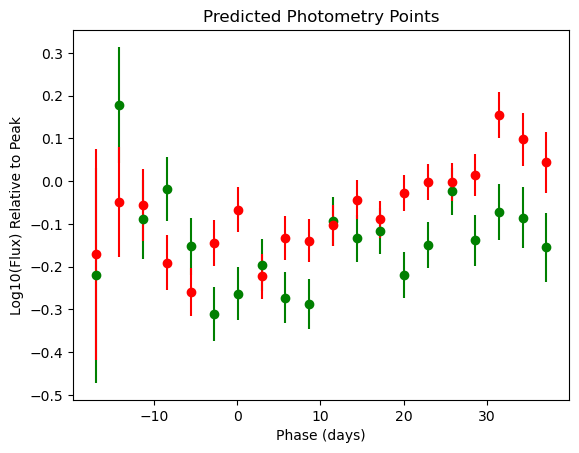

In [493]:
time = np.arange(-17,40,(17+40)/20)
gband = np.ones(20)*4830
rband = np.ones(20)*6260
bands = np.append(gband, rband)
times = np.append(time, time)

phases, predictions, dev = model.predict_photometry_points(
    wavelengths = np.asarray(bands),
    phases = np.asarray(times),
    show=True
)

In [406]:
gp_data = {}

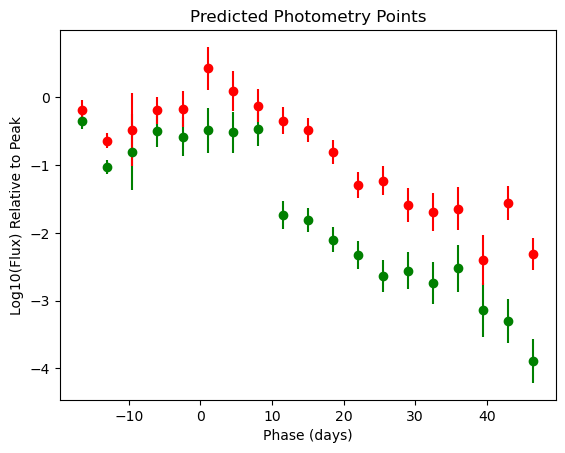

In [472]:
# model = SNModel(
#     surface="maven2peakobjs_GP_models.fits",
# )
model = sn_model 

# model.predict_lightcurve(-20.0, 45.0, 5000)

time = np.arange(-20,50,(50+20)/20)
gband = np.ones(20)*4830
rband = np.ones(20)*6260
bands = np.append(gband, rband)
times = np.append(time, time)

phases, predictions, dev = model.predict_photometry_points(
    wavelengths = np.asarray(bands),
    phases = np.asarray(times),
    show=True
)

In [473]:
gp_data.update({"obj10":[phases, predictions, dev]})

In [ ]:
# gp_data

{'obj1': [array([-20. , -16.5, -13. ,  -9.5,  -6. ,  -2.5,   1. ,   4.5,   8. ,
          11.5,  15. ,  18.5,  22. ,  25.5,  29. ,  32.5,  36. ,  39.5,
          43. ,  46.5, -20. , -16.5, -13. ,  -9.5,  -6. ,  -2.5,   1. ,
           4.5,   8. ,  11.5,  15. ,  18.5,  22. ,  25.5,  29. ,  32.5,
          36. ,  39.5,  43. ,  46.5]),
  array([            nan, -1.61745692e-01, -7.86485451e-01, -7.66517105e-01,
         -7.40008938e-01, -5.97987846e-01,  2.75884922e-01, -6.12922916e-01,
         -7.12198016e-01, -1.18300197e+00, -1.40359573e+00, -1.88059528e+00,
         -2.14840350e+00, -2.00180824e+00, -2.27626979e+00, -2.85943222e+00,
         -2.92065516e+00, -3.57321958e+00, -3.61197690e+00, -3.62102449e+00,
                     nan, -9.48114780e-04, -5.23110702e-01, -2.33443073e-01,
         -5.67494817e-01, -2.97291490e-01, -3.14178021e-01, -3.66636381e-02,
         -4.04979589e-01, -5.24131096e-01, -8.65831134e-01, -1.11254473e+00,
         -1.41088956e+00, -1.51269701e+00, -1.778

In [474]:
import pickle

with open('test_gp_lcs_20rsc21pb.pkl', 'wb') as f:
    pickle.dump(gp_data, f)